
# Assignment 2 — Encoding & Transformation Impact

**Course:** Feature Engineering & MLOps  
**Assignment:** 2  
**Topics:** One-Hot Encoding (2.1) + Transformations & Model Comparison (2.2)

## Objective

This notebook completes both required parts of Assignment 2:

- **Part 2.1:** One-hot encode the nominal categorical columns `city`, `course`, and `batch_type`.
- **Part 2.2:** Transform the right-skewed `weekly_study_hours` feature and compare **Linear Regression** and **Decision Tree Regressor** before vs. after transformation.

The experiment keeps the train/test rows, random seed, model settings, and all other features identical so that the measured difference is attributable to the representation of `weekly_study_hours`.


## 1. Imports and Dataset

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

DATA_PATH = Path("data/raw/student_performance_raw.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/student_performance_raw(1).csv")

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Dataset path: /mnt/data/student_performance_raw(1).csv
Rows: 600
Columns: 17


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score
0,1447,Patna,2,JEE Main,Weekday,18,2026-05-27,91.1000,0.8000,<5L,65.2000,68.1000,59.0000,72.2000,1,Need more practice sheets for weak topics,42.0000
1,1405,Patna,2,NEET,Weekday,16,2024-07-08,91.9000,2.4000,NaN,64.9000,82.0000,88.4000,100.0000,3,Would like more one-on-one mentoring,62.0000
2,1510,Mumbai,1,JEE Main,Weekday,18,2025-03-17,67.1000,6.7000,5-10L,90.1000,86.5000,91.1000,76.4000,5,"Great teaching pace, doubts cleared quickly",56.4000
3,1456,Delhi,1,NEET,Weekday,18,2025-06-16,70.7000,2.0000,10-20L,29.7000,19.4000,24.9000,NaN,3,Need more practice sheets for weak topics,31.7000
4,1202,Patna,2,JEE Advanced,Weekday,17,2026-04-16,69.3000,6.5000,>20L,70.0000,63.8000,74.5000,69.1000,4,Need more practice sheets for weak topics,44.5000



## 2. Dataset Roles and Nominal Categorical Features

We identify

- `city`
- `course`
- `batch_type`

as the categorical features for Part 2.1.

They are **nominal** because their categories represent labels/groups and do not have a meaningful natural ranking. For example, one city is not inherently "higher" or "lower" than another city, and course or batch labels do not form an ordered scale. Therefore, assigning ordinal numbers to these categories would incorrectly imply an order that does not exist.

For Part 2.2, `weekly_study_hours` is the transformation target, while `attendance_pct`, `prev_exam_score`, and `doubt_sessions_attended` are additional numeric predictors. `final_score` is the continuous regression target.


In [2]:

categorical_cols = ["city", "course", "batch_type"]
numeric_predictors = [
    "weekly_study_hours",
    "attendance_pct",
    "prev_exam_score",
    "doubt_sessions_attended",
]
target = "final_score"

print("Categorical columns:", categorical_cols)
print("Numeric predictors:", numeric_predictors)
print("Regression target:", target)

display(df[categorical_cols + numeric_predictors + [target]].dtypes.to_frame("dtype"))


Categorical columns: ['city', 'course', 'batch_type']
Numeric predictors: ['weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended']
Regression target: final_score


,dtype
city,object
course,object
batch_type,object
weekly_study_hours,float64
attendance_pct,float64
prev_exam_score,float64
doubt_sessions_attended,int64
final_score,float64



## 3. Missing-Value Handling and Train/Test Discipline

 `weekly_study_hours` and `prev_exam_score` contain missing values and says they must be imputed before modeling, while also requiring fitting only on training data.


In [3]:

random_state = 42

X_raw = df[categorical_cols + numeric_predictors].copy()
y = df[target].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=random_state,
)

print(f"Training rows: {len(X_train_raw)}")
print(f"Test rows:     {len(X_test_raw)}")
print(f"Training proportion: {len(X_train_raw) / len(X_raw):.0%}")
print(f"Test proportion:     {len(X_test_raw) / len(X_raw):.0%}")

print("\nMissing values in modeling predictors:")
display(X_raw.isna().sum().to_frame("missing_count"))

numeric_imputer = SimpleImputer(strategy="median")
numeric_imputer.fit(X_train_raw[numeric_predictors])

X_train_num = pd.DataFrame(
    numeric_imputer.transform(X_train_raw[numeric_predictors]),
    columns=numeric_predictors,
    index=X_train_raw.index,
)
X_test_num = pd.DataFrame(
    numeric_imputer.transform(X_test_raw[numeric_predictors]),
    columns=numeric_predictors,
    index=X_test_raw.index,
)

print("\nTraining-only numeric fill values:")
display(pd.Series(numeric_imputer.statistics_, index=numeric_predictors, name="median_fill_value").to_frame())

assert X_train_num.isna().sum().sum() == 0
assert X_test_num.isna().sum().sum() == 0
print("PASS: Numeric predictors contain no missing values after train-only imputation.")


Training rows: 480
Test rows:     120
Training proportion: 80%
Test proportion:     20%

Missing values in modeling predictors:


,missing_count
city,0
course,0
batch_type,0
weekly_study_hours,36
attendance_pct,0
prev_exam_score,25
doubt_sessions_attended,0



Training-only numeric fill values:


,median_fill_value
weekly_study_hours,5.0000
attendance_pct,78.3500
prev_exam_score,66.1000
doubt_sessions_attended,4.0000


PASS: Numeric predictors contain no missing values after train-only imputation.


## 4. Part 2.1 — One-Hot Encoding

In [4]:

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

# Fit ONLY on training categorical data.
encoder.fit(X_train_raw[categorical_cols])

X_train_cat = pd.DataFrame(
    encoder.transform(X_train_raw[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train_raw.index,
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test_raw[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test_raw.index,
)

print("OneHotEncoder configuration:")
print("handle_unknown =", encoder.handle_unknown)
print("Number of encoded categorical columns:", X_train_cat.shape[1])

display(X_train_cat.head())


OneHotEncoder configuration:
handle_unknown = ignore
Number of encoded categorical columns: 15


,city_Bengaluru,city_Delhi,city_Hyderabad,city_Kota,city_Lucknow,city_Mumbai,city_Patna,city_Pune,course_Foundation,course_JEE Advanced,course_JEE Main,course_NEET,batch_type_Crash Course,batch_type_Weekday,batch_type_Weekend
145,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
9,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
375,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
523,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
188,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000


### 4.1 Dataset Dimensionality Before vs. After Encoding

In [5]:

before_columns = len(df.columns)
encoded_feature_count = X_train_cat.shape[1]
model_numeric_count = len(numeric_predictors)
after_model_columns = encoded_feature_count + model_numeric_count

dimension_table = pd.DataFrame({
    "representation": [
        "Original full dataset",
        "Modeling feature set before one-hot encoding",
        "Modeling feature set after one-hot encoding",
    ],
    "number_of_columns": [
        before_columns,
        len(categorical_cols) + model_numeric_count,
        after_model_columns,
    ],
})

display(dimension_table)

print(
    f"The full raw dataset has {before_columns} columns. "
    f"The assignment's modeling feature set has {len(categorical_cols) + model_numeric_count} "
    f"columns before encoding and {after_model_columns} after encoding. "
    f"One-hot encoding increases dimensionality because each category becomes a separate binary feature."
)


,representation,number_of_columns
0,Original full dataset,17
1,Modeling feature set before one-hot encoding,7
2,Modeling feature set after one-hot encoding,19


The full raw dataset has 17 columns. The assignment's modeling feature set has 7 columns before encoding and 19 after encoding. One-hot encoding increases dimensionality because each category becomes a separate binary feature.


### 4.2 Test-Only Categories and `handle_unknown='ignore'`

In [6]:

test_only_categories = {}

for col in categorical_cols:
    train_categories = set(X_train_raw[col].dropna().unique())
    test_categories = set(X_test_raw[col].dropna().unique())
    test_only = sorted(test_categories - train_categories)
    test_only_categories[col] = test_only

test_only_table = pd.DataFrame([
    {
        "column": col,
        "test_only_categories": ", ".join(map(str, cats)) if cats else "None",
        "count": len(cats),
    }
    for col, cats in test_only_categories.items()
])

display(test_only_table)

# Demonstrate that transformation succeeds regardless of whether test-only
# categories exist. With handle_unknown='ignore', an unseen category is encoded
# as all zeros across the relevant one-hot columns rather than raising an error.
X_test_cat_again = encoder.transform(X_test_raw[categorical_cols])

assert X_test_cat_again.shape[0] == len(X_test_raw)
assert X_test_cat_again.shape[1] == X_train_cat.shape[1]

print(
    "PASS: The test categorical data was transformed without category errors. "
    "`handle_unknown='ignore'` prevents unseen test categories from causing an exception."
)


,column,test_only_categories,count
0,city,None,0
1,course,None,0
2,batch_type,None,0


PASS: The test categorical data was transformed without category errors. `handle_unknown='ignore'` prevents unseen test categories from causing an exception.



## 5. Part 2.2 — Diagnose `weekly_study_hours` Skewness



In [7]:

weekly = df["weekly_study_hours"]

skewness = weekly.skew()
value_min = weekly.min()
value_max = weekly.max()
missing_count = weekly.isna().sum()

skewness_table = pd.DataFrame({
    "feature": ["weekly_study_hours"],
    "min": [value_min],
    "max": [value_max],
    "skewness": [skewness],
    "missing_count": [missing_count],
})

display(skewness_table)

if skewness > 1:
    interpretation = "meaningfully right-skewed"
elif skewness > 0.5:
    interpretation = "moderately right-skewed"
else:
    interpretation = "not strongly right-skewed"

print(f"Interpretation: weekly_study_hours is {interpretation}.")


,feature,min,max,skewness,missing_count
0,weekly_study_hours,0.2000,31.4000,1.5132,36


Interpretation: weekly_study_hours is meaningfully right-skewed.



## 6. Choose the Transformation

**Chosen transformation: `np.log1p(x)`**

The observed `weekly_study_hours` values are positive (minimum is above zero) and the feature is strongly right-skewed. A logarithmic transformation is therefore a natural choice for compressing large values more than small values and reducing the influence of the long right tail.

`np.log1p(x)` is used instead of `np.log(x)` because it is numerically well-behaved around zero and is valid for non-negative values. The transformation is applied **after the training-fitted median imputation**, so no missing values are passed into the logarithm.


In [8]:

# Apply the selected transformation to the imputed weekly_study_hours feature.
X_train_num_after = X_train_num.copy()
X_test_num_after = X_test_num.copy()

X_train_num_after["weekly_study_hours"] = np.log1p(
    X_train_num_after["weekly_study_hours"]
)
X_test_num_after["weekly_study_hours"] = np.log1p(
    X_test_num_after["weekly_study_hours"]
)

transformation_summary = pd.DataFrame({
    "version": ["Before", "After"],
    "weekly_study_hours_mean": [
        X_train_num["weekly_study_hours"].mean(),
        X_train_num_after["weekly_study_hours"].mean(),
    ],
    "weekly_study_hours_std": [
        X_train_num["weekly_study_hours"].std(),
        X_train_num_after["weekly_study_hours"].std(),
    ],
    "weekly_study_hours_skewness": [
        X_train_num["weekly_study_hours"].skew(),
        X_train_num_after["weekly_study_hours"].skew(),
    ],
})

display(transformation_summary)


,version,weekly_study_hours_mean,weekly_study_hours_std,weekly_study_hours_skewness
0,Before,6.0088,4.2418,1.5957
1,After,1.7831,0.5774,-0.0392



## 7. Build Identical Before/After Feature Sets

Both versions contain exactly the same predictors except for `weekly_study_hours`:

- One-hot encoded `city`
- One-hot encoded `course`
- One-hot encoded `batch_type`
- `attendance_pct`
- `prev_exam_score`
- `doubt_sessions_attended`
- `weekly_study_hours`

**Version A (Before):** raw/imputed `weekly_study_hours`  
**Version B (After):** `log1p` transformed `weekly_study_hours`

The categorical encoder and numeric imputer are both fitted using training data only, and the same train/test row split is used throughout.


In [9]:

# Align by index so train/test rows remain exactly the same.
X_train_before = pd.concat(
    [
        X_train_cat,
        X_train_num[["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]],
    ],
    axis=1,
)

X_test_before = pd.concat(
    [
        X_test_cat,
        X_test_num[["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]],
    ],
    axis=1,
)

X_train_after = pd.concat(
    [
        X_train_cat,
        X_train_num_after[["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]],
    ],
    axis=1,
)

X_test_after = pd.concat(
    [
        X_test_cat,
        X_test_num_after[["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]],
    ],
    axis=1,
)

assert list(X_train_before.columns) == list(X_train_after.columns)
assert list(X_test_before.columns) == list(X_test_after.columns)
assert X_train_before.drop(columns=["weekly_study_hours"]).equals(
    X_train_after.drop(columns=["weekly_study_hours"])
)
assert X_test_before.drop(columns=["weekly_study_hours"]).equals(
    X_test_after.drop(columns=["weekly_study_hours"])
)

print("Feature count before:", X_train_before.shape[1])
print("Feature count after: ", X_train_after.shape[1])
print("Only weekly_study_hours changes between the two versions.")


Feature count before: 19
Feature count after:  19
Only weekly_study_hours changes between the two versions.



## 8. Train the Four Required Models


In [10]:

tree_random_state = 42
tree_max_depth = 5

models = {
    "LinearRegression_Before": (
        LinearRegression(),
        X_train_before,
        X_test_before,
    ),
    "LinearRegression_After": (
        LinearRegression(),
        X_train_after,
        X_test_after,
    ),
    "DecisionTree_Before": (
        DecisionTreeRegressor(
            random_state=tree_random_state,
            max_depth=tree_max_depth,
        ),
        X_train_before,
        X_test_before,
    ),
    "DecisionTree_After": (
        DecisionTreeRegressor(
            random_state=tree_random_state,
            max_depth=tree_max_depth,
        ),
        X_train_after,
        X_test_after,
    ),
}

results = []

for model_name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    predictions = model.predict(Xte)

    results.append({
        "model": model_name.split("_")[0],
        "feature_version": model_name.split("_")[1],
        "R2": r2_score(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
    })

results_df = pd.DataFrame(results)

display(results_df)

print("PASS: Four required models trained using the same train/test split.")


,model,feature_version,R2,RMSE
0,LinearRegression,Before,0.5930,6.3915
1,LinearRegression,After,0.5734,6.5435
2,DecisionTree,Before,0.4461,7.4564
3,DecisionTree,After,0.4461,7.4564


PASS: Four required models trained using the same train/test split.


## 9. Required Summary Table — R² and RMSE

In [11]:

summary_table = results_df.copy()

summary_table["model_version"] = (
    summary_table["model"] + " — " + summary_table["feature_version"]
)

summary_table = summary_table[
    ["model_version", "model", "feature_version", "R2", "RMSE"]
].sort_values(
    ["model", "feature_version"]
).reset_index(drop=True)

display(summary_table.style.format({"R2": "{:.4f}", "RMSE": "{:.4f}"}))


,model_version,model,feature_version,R2,RMSE
0,DecisionTree — After,DecisionTree,After,0.4461,7.4564
1,DecisionTree — Before,DecisionTree,Before,0.4461,7.4564
2,LinearRegression — After,LinearRegression,After,0.5734,6.5435
3,LinearRegression — Before,LinearRegression,Before,0.5930,6.3915


## 10. Before vs. After R² Comparison

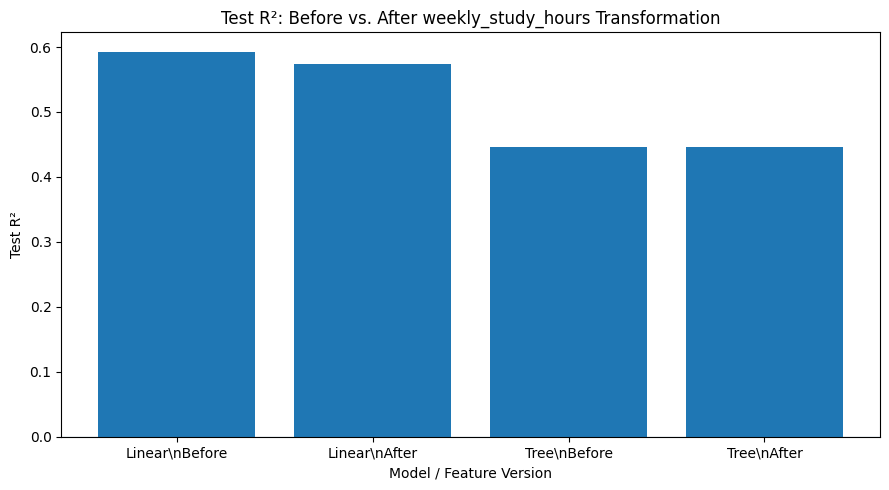

In [12]:
plot_labels = [
    "Linear\\nBefore",
    "Linear\\nAfter",
    "Tree\\nBefore",
    "Tree\\nAfter",
]

plot_values = [
    results_df.loc[
        (results_df["model"] == "LinearRegression") &
        (results_df["feature_version"] == "Before"), "R2"
    ].iloc[0],
    results_df.loc[
        (results_df["model"] == "LinearRegression") &
        (results_df["feature_version"] == "After"), "R2"
    ].iloc[0],
    results_df.loc[
        (results_df["model"] == "DecisionTree") &
        (results_df["feature_version"] == "Before"), "R2"
    ].iloc[0],
    results_df.loc[
        (results_df["model"] == "DecisionTree") &
        (results_df["feature_version"] == "After"), "R2"
    ].iloc[0],
]

plt.figure(figsize=(9, 5))
plt.bar(plot_labels, plot_values)
plt.ylabel("Test R²")
plt.xlabel("Model / Feature Version")
plt.title("Test R²: Before vs. After weekly_study_hours Transformation")
plt.axhline(0, linewidth=0.8)
plt.tight_layout()
plt.show()



## 11. Quantify the Change

The following table makes the transformation effect explicit by calculating the change from Before to After for each model family.


In [13]:

pivot_r2 = results_df.pivot(index="model", columns="feature_version", values="R2")
pivot_rmse = results_df.pivot(index="model", columns="feature_version", values="RMSE")

effect_table = pd.DataFrame({
    "model": pivot_r2.index,
    "R2_before": pivot_r2["Before"].values,
    "R2_after": pivot_r2["After"].values,
    "R2_change": (pivot_r2["After"] - pivot_r2["Before"]).values,
    "RMSE_before": pivot_rmse["Before"].values,
    "RMSE_after": pivot_rmse["After"].values,
    "RMSE_change": (pivot_rmse["After"] - pivot_rmse["Before"]).values,
})

display(effect_table.style.format({
    "R2_before": "{:.4f}",
    "R2_after": "{:.4f}",
    "R2_change": "{:+.4f}",
    "RMSE_before": "{:.4f}",
    "RMSE_after": "{:.4f}",
    "RMSE_change": "{:+.4f}",
}))


,model,R2_before,R2_after,R2_change,RMSE_before,RMSE_after,RMSE_change
0,DecisionTree,0.4461,0.4461,+0.0000,7.4564,7.4564,+0.0000
1,LinearRegression,0.5930,0.5734,-0.0196,6.3915,6.5435,+0.1520



## 12. Conclusion

The results show that Linear Regression changed noticeably after the log1p transformation, with R² decreasing from 0.5930 to 0.5734 and RMSE increasing from 6.3915 to 6.5435. This happens because Linear Regression uses the feature's raw numerical values directly through learned coefficients, so transforming weekly_study_hours changes the numerical relationship the model can represent with a linear coefficient. In contrast, the Decision Tree's performance remained exactly the same (R² = 0.4461, RMSE = 7.4564) because it uses threshold-based splits rather than coefficients or gradients over the raw feature values. Since log1p is a monotonic transformation, it preserves the ordering of weekly_study_hours, allowing the tree to make effectively the same splits using different threshold values.


In [14]:

linear_before_r2 = effect_table.loc[
    effect_table["model"] == "LinearRegression", "R2_before"
].iloc[0]
linear_after_r2 = effect_table.loc[
    effect_table["model"] == "LinearRegression", "R2_after"
].iloc[0]
tree_before_r2 = effect_table.loc[
    effect_table["model"] == "DecisionTree", "R2_before"
].iloc[0]
tree_after_r2 = effect_table.loc[
    effect_table["model"] == "DecisionTree", "R2_after"
].iloc[0]

print(
    f"On this dataset, Linear Regression R² changed from {linear_before_r2:.4f} "
    f"to {linear_after_r2:.4f} after log1p transformation, while the Decision Tree "
    f"R² changed from {tree_before_r2:.4f} to {tree_after_r2:.4f}. "
    "Linear Regression uses coefficients over raw feature values, so the transformed "
    "feature changes the functional representation available to the model. A Decision "
    "Tree instead relies on threshold splits; because log1p is monotonic, it preserves "
    "the ordering of observations and therefore can reproduce essentially the same "
    "partitions using transformed thresholds."
)


On this dataset, Linear Regression R² changed from 0.5930 to 0.5734 after log1p transformation, while the Decision Tree R² changed from 0.4461 to 0.4461. Linear Regression uses coefficients over raw feature values, so the transformed feature changes the functional representation available to the model. A Decision Tree instead relies on threshold splits; because log1p is monotonic, it preserves the ordering of observations and therefore can reproduce essentially the same partitions using transformed thresholds.



## 13. Optional Bonus — K-Nearest Neighbors Regressor

KNN is a genuinely distance-based algorithm. For the bonus, the same Before/After feature representations are used with identical `n_neighbors`, so the only change remains the representation of `weekly_study_hours`.

Because KNN computes distances between rows, the scale and distribution of numeric features can affect which observations are considered nearest. A transformation that compresses the long right tail can therefore change neighborhood relationships and potentially have a larger effect than it does for the other model families.


In [15]:

knn_n_neighbors = 5

knn_results = []

for version, Xtr, Xte in [
    ("Before", X_train_before, X_test_before),
    ("After", X_train_after, X_test_after),
]:
    knn = KNeighborsRegressor(n_neighbors=knn_n_neighbors)
    knn.fit(Xtr, y_train)
    pred = knn.predict(Xte)

    knn_results.append({
        "model": "KNN",
        "feature_version": version,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    })

knn_results_df = pd.DataFrame(knn_results)
display(knn_results_df)

knn_r2_change = (
    knn_results_df.loc[knn_results_df["feature_version"] == "After", "R2"].iloc[0]
    - knn_results_df.loc[knn_results_df["feature_version"] == "Before", "R2"].iloc[0]
)

print(f"KNN R² change (After - Before): {knn_r2_change:+.4f}")
print(
    "Interpretation: KNN is directly sensitive to distances between rows, so a "
    "transformation can alter neighborhood relationships. Whether its improvement "
    "is larger than Linear Regression is an empirical question answered by the values above."
)


,model,feature_version,R2,RMSE
0,KNN,Before,0.5348,6.8331
1,KNN,After,0.2194,8.8516


KNN R² change (After - Before): -0.3154
Interpretation: KNN is directly sensitive to distances between rows, so a transformation can alter neighborhood relationships. Whether its improvement is larger than Linear Regression is an empirical question answered by the values above.
